In [1]:
import pandas as pd
df = pd.read_csv('outputs/gcpi4_series.csv', index_col=0, parse_dates=True)
# Tienes columnas: HCP, HSP, MCP, MSP — inflación mensual YoY

In [2]:
import pandas as pd

df = pd.read_csv('outputs/gcpi4_series.csv', index_col=0, parse_dates=True)

GRUPOS = {
    'MWP':  'inf_HOMBRE_CON_PAREJA',   # Male With Partner
    'MWoP': 'inf_HOMBRE_SIN_PAREJA',   # Male Without Partner
    'FWP':  'inf_MUJER_CON_PAREJA',    # Female With Partner
    'FWoP': 'inf_MUJER_SIN_PAREJA'     # Female Without Partner
}

df_inf = df[[v for v in GRUPOS.values()]].dropna()
df_inf.columns = list(GRUPOS.keys())

print(f"Observaciones disponibles: {len(df_inf)}")
print(f"Período: {df_inf.index[0]} → {df_inf.index[-1]}")
print()
print(df_inf.describe().round(4))

Observaciones disponibles: 36
Período: 2023-01-01 00:00:00 → 2025-12-01 00:00:00

           MWP     MWoP      FWP     FWoP
count  36.0000  36.0000  36.0000  36.0000
mean    4.4279   4.6665   4.3942   4.4148
std     0.9910   1.0154   0.9391   0.9751
min     3.2615   3.5923   3.3567   3.2679
25%     3.6606   3.9976   3.7264   3.7527
50%     4.2918   4.4787   4.2362   4.2537
75%     4.6262   4.8829   4.5540   4.6231
max     7.2127   7.5273   7.0729   7.1565


In [3]:
from statsmodels.tsa.stattools import adfuller

print("ADF Test — Stationarity Check")
print("H0: series has a unit root (non-stationary)")
print("Reject H0 if p-value < 0.05\n")

for grupo in df_inf.columns:
    result = adfuller(df_inf[grupo], autolag='AIC')
    p = result[1]
    stat = result[0]
    conclusion = "✅ STATIONARY" if p < 0.05 else "⚠️  NON-STATIONARY"
    print(f"{grupo}: ADF stat = {stat:.4f}, p-value = {p:.4f}  →  {conclusion}")

ADF Test — Stationarity Check
H0: series has a unit root (non-stationary)
Reject H0 if p-value < 0.05

MWP: ADF stat = -3.4316, p-value = 0.0099  →  ✅ STATIONARY
MWoP: ADF stat = -4.0157, p-value = 0.0013  →  ✅ STATIONARY
FWP: ADF stat = -3.4863, p-value = 0.0083  →  ✅ STATIONARY
FWoP: ADF stat = -3.4305, p-value = 0.0100  →  ✅ STATIONARY


In [4]:
# Instalar pmdarima — solo necesitas hacer esto una vez
import sys
!{sys.executable} -m pip install pmdarima

In [5]:
# Actualizar statsmodels a versión compatible con pmdarima
import sys
!{sys.executable} -m pip install --upgrade statsmodels pmdarima

In [7]:
# Celda 1 — Cargar datos
import pandas as pd

df = pd.read_csv('outputs/gcpi4_series.csv', index_col=0, parse_dates=True)

GRUPOS = {
    'MWP':  'inf_HOMBRE_CON_PAREJA',
    'MWoP': 'inf_HOMBRE_SIN_PAREJA',
    'FWP':  'inf_MUJER_CON_PAREJA',
    'FWoP': 'inf_MUJER_SIN_PAREJA'
}

df_inf = df[[v for v in GRUPOS.values()]].dropna()
df_inf.columns = list(GRUPOS.keys())
print(f"✅ {len(df_inf)} observaciones: {df_inf.index[0].date()} → {df_inf.index[-1].date()}")

✅ 36 observaciones: 2023-01-01 → 2025-12-01


In [8]:
# Celda 2 — Fit SARIMA manualmente para cada grupo
# Usamos SARIMAX de statsmodels — mismo modelo, sin depender de pmdarima
# Orden (1,0,1)(1,0,1,12): AR=1, no diferencia, MA=1, estacionalidad anual
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

modelos = {}
for grupo in df_inf.columns:
    modelo = SARIMAX(
        df_inf[grupo],
        order=(1, 0, 1),           # (p, d, q) — no-seasonal
        seasonal_order=(1, 0, 1, 12)  # (P, D, Q, m) — seasonal anual
    ).fit(disp=False)
    
    modelos[grupo] = modelo
    print(f"{grupo}: AIC = {modelo.aic:.2f}  |  BIC = {modelo.bic:.2f}")

MWP: AIC = 26.36  |  BIC = 34.28
MWoP: AIC = 17.24  |  BIC = 25.16
FWP: AIC = 24.98  |  BIC = 32.89
FWoP: AIC = 26.54  |  BIC = 34.45


In [9]:
# Celda 3 — Generar forecast 12 meses (Jan 2026 – Dec 2026)
import pandas as pd
import numpy as np

fechas_fc = pd.date_range('2026-01', periods=12, freq='MS')
resultados = {}

for grupo, modelo in modelos.items():
    fc = modelo.get_forecast(steps=12)
    mean = fc.predicted_mean.values
    ci   = fc.conf_int(alpha=0.05).values  # intervalo de confianza 95%
    
    resultados[grupo] = {
        'forecast': mean,
        'lower':    ci[:, 0],
        'upper':    ci[:, 1]
    }

# Tabla resumen
print(f"{'Month':<12} {'MWP':>7} {'MWoP':>7} {'FWP':>7} {'FWoP':>7}")
print("-" * 45)
for i, fecha in enumerate(fechas_fc):
    row = f"{fecha.strftime('%b %Y'):<12}"
    for grupo in ['MWP', 'MWoP', 'FWP', 'FWoP']:
        row += f" {resultados[grupo]['forecast'][i]:>7.2f}%"
    print(row)

Month            MWP    MWoP     FWP    FWoP
---------------------------------------------
Jan 2026        3.73%    3.96%    3.79%    3.81%
Feb 2026        3.84%    4.06%    3.91%    3.92%
Mar 2026        3.97%    4.17%    4.02%    4.02%
Apr 2026        3.98%    4.18%    4.01%    4.01%
May 2026        3.82%    4.08%    3.83%    3.82%
Jun 2026        3.91%    4.14%    3.92%    3.90%
Jul 2026        4.14%    4.30%    4.15%    4.14%
Aug 2026        4.34%    4.46%    4.35%    4.35%
Sep 2026        4.33%    4.47%    4.34%    4.33%
Oct 2026        4.40%    4.55%    4.41%    4.42%
Nov 2026        4.27%    4.47%    4.29%    4.30%
Dec 2026        4.37%    4.55%    4.39%    4.42%


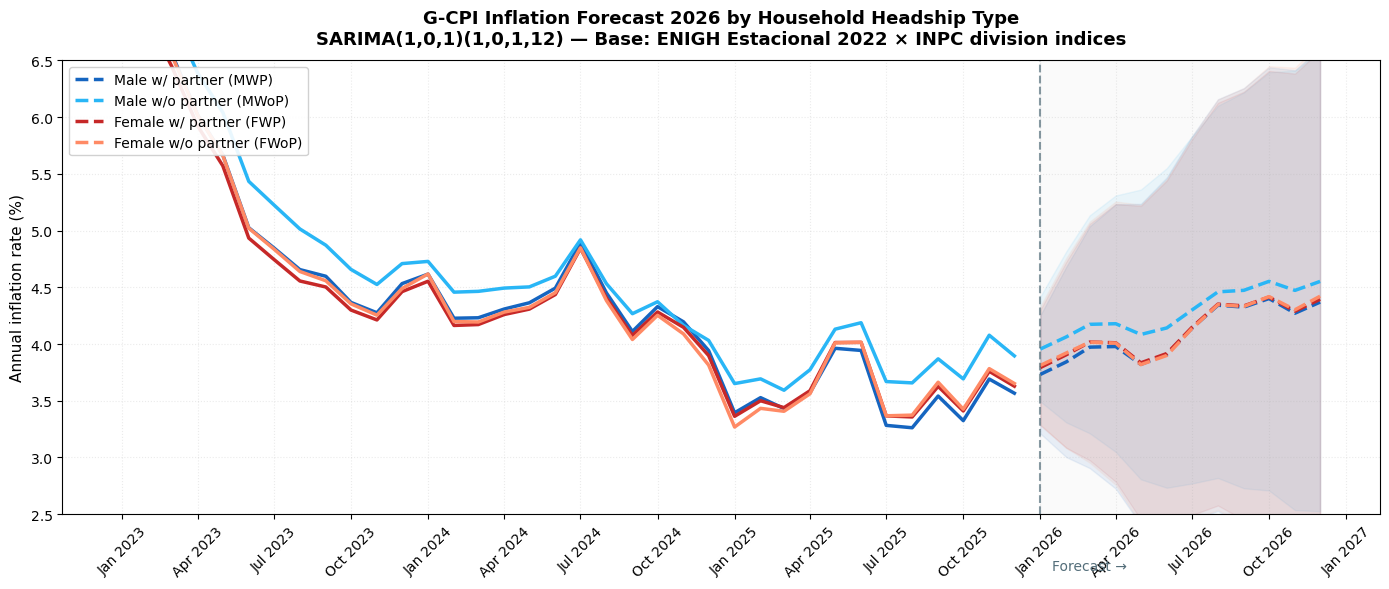

✅ Saved: outputs/gcpi_forecast_2026_combined.png


In [10]:
# Celda 5 — Gráfica combinada para presentación (todas las series en un solo panel)
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 6))

colores = {'MWP':'#1565C0', 'MWoP':'#29B6F6', 'FWP':'#C62828', 'FWoP':'#FF8A65'}
labels  = {'MWP':'Male w/ partner (MWP)', 'MWoP':'Male w/o partner (MWoP)',
           'FWP':'Female w/ partner (FWP)', 'FWoP':'Female w/o partner (FWoP)'}

for grupo in ['MWP', 'MWoP', 'FWP', 'FWoP']:
    r   = resultados[grupo]
    col = colores[grupo]
    
    # Histórico
    ax.plot(df_inf.index, df_inf[grupo],
            color=col, linewidth=2.5)
    
    # Forecast
    ax.plot(fechas_fc, r['forecast'],
            color=col, linewidth=2.5, linestyle='--', label=labels[grupo])
    
    # IC 95%
    ax.fill_between(fechas_fc, r['lower'], r['upper'],
                    alpha=0.08, color=col)

# Línea de separación histórico/forecast
ax.axvline(pd.Timestamp('2026-01'), color='#546E7A',
           linestyle='--', linewidth=1.5, alpha=0.7)
ax.text(pd.Timestamp('2026-01-15'), ax.get_ylim()[0] + 0.15,
        'Forecast →', fontsize=10, color='#546E7A')

# Zona sombreada forecast
ax.axvspan(pd.Timestamp('2026-01'), fechas_fc[-1],
           alpha=0.04, color='gray')

ax.set_title('G-CPI Inflation Forecast 2026 by Household Headship Type\n'
             'SARIMA(1,0,1)(1,0,1,12) — Base: ENIGH Estacional 2022 × INPC division indices',
             fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Annual inflation rate (%)', fontsize=11)
ax.set_xlabel('')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=10, loc='upper left', framealpha=0.9)
ax.grid(alpha=0.25, linestyle=':')
ax.set_ylim(2.5, 6.5)

plt.tight_layout()
plt.savefig('outputs/gcpi_forecast_2026_combined.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: outputs/gcpi_forecast_2026_combined.png")

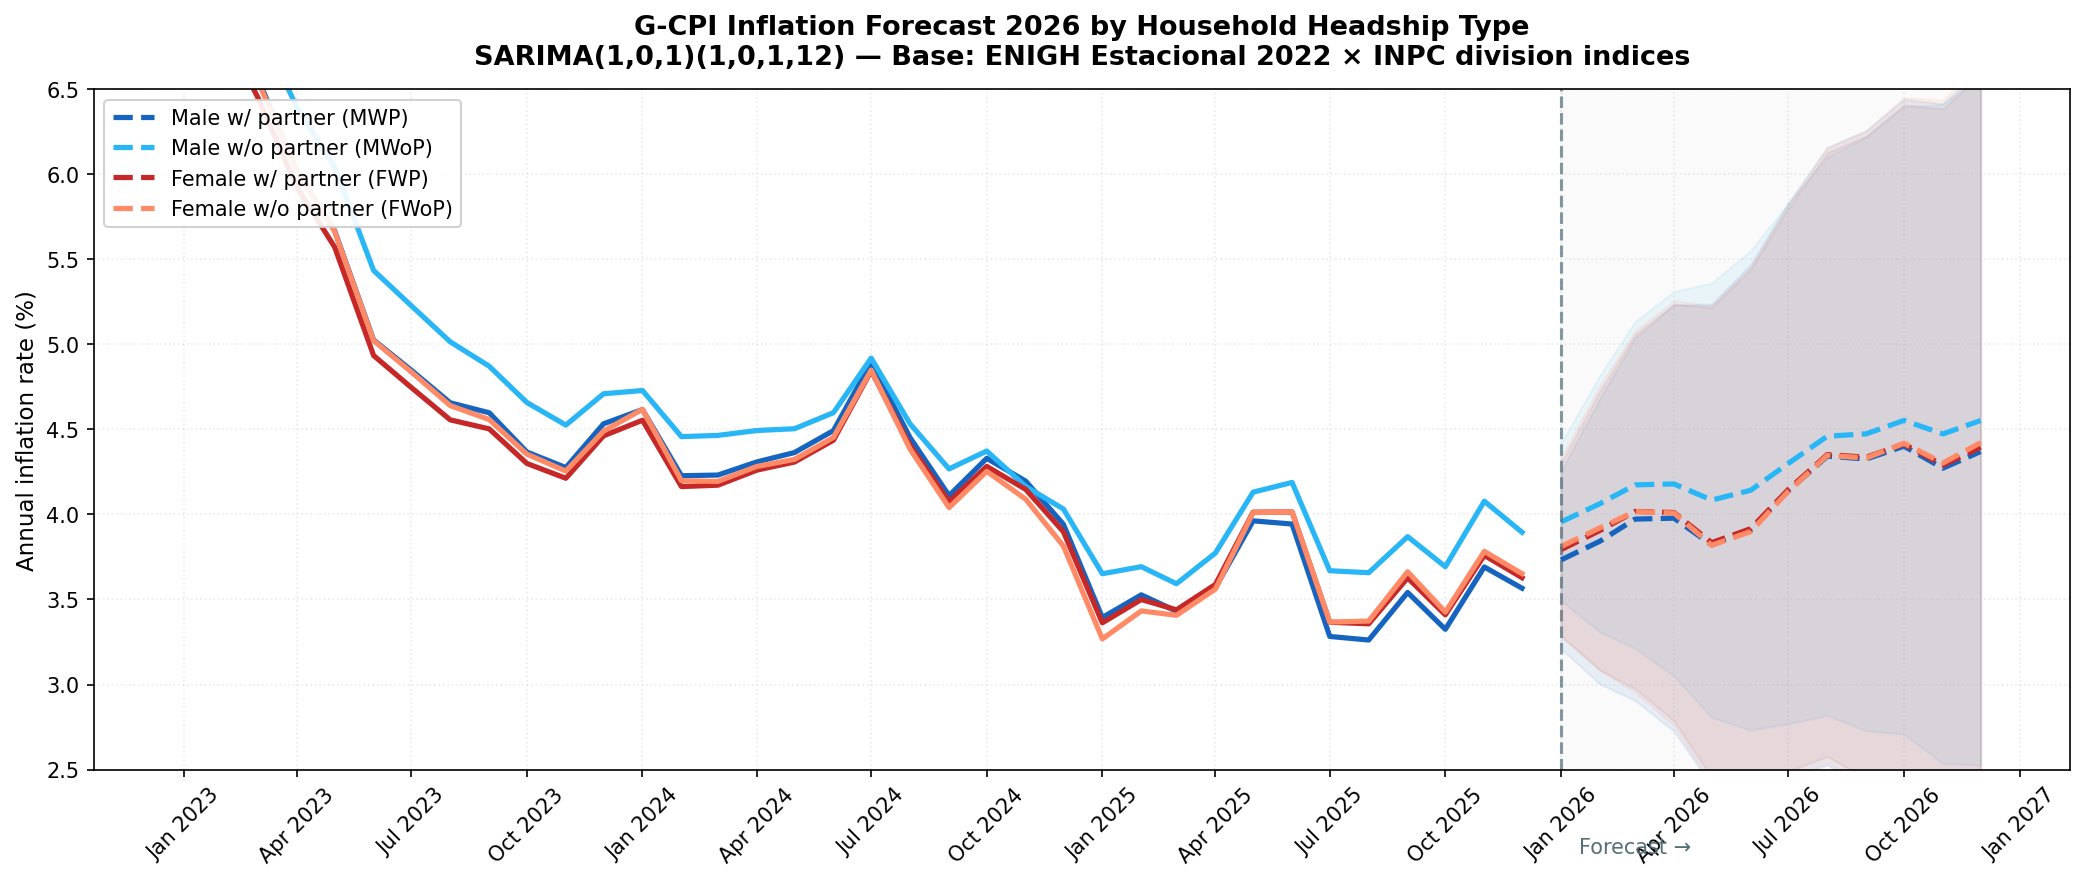

In [11]:
# Mostrar la gráfica guardada para verificar
from IPython.display import Image
Image('outputs/gcpi_forecast_2026_combined.png')

In [12]:
# Verificar que el archivo existe y tiene buen tamaño
import os
path = 'outputs/gcpi_forecast_2026_combined.png'
size = os.path.getsize(path)
print(f"✅ Archivo: {path}")
print(f"   Tamaño: {size/1024:.1f} KB")
print(f"   {'OK — imagen completa' if size > 50000 else '⚠️ muy pequeña, algo salió mal'}")

✅ Archivo: outputs/gcpi_forecast_2026_combined.png
   Tamaño: 257.2 KB
   OK — imagen completa


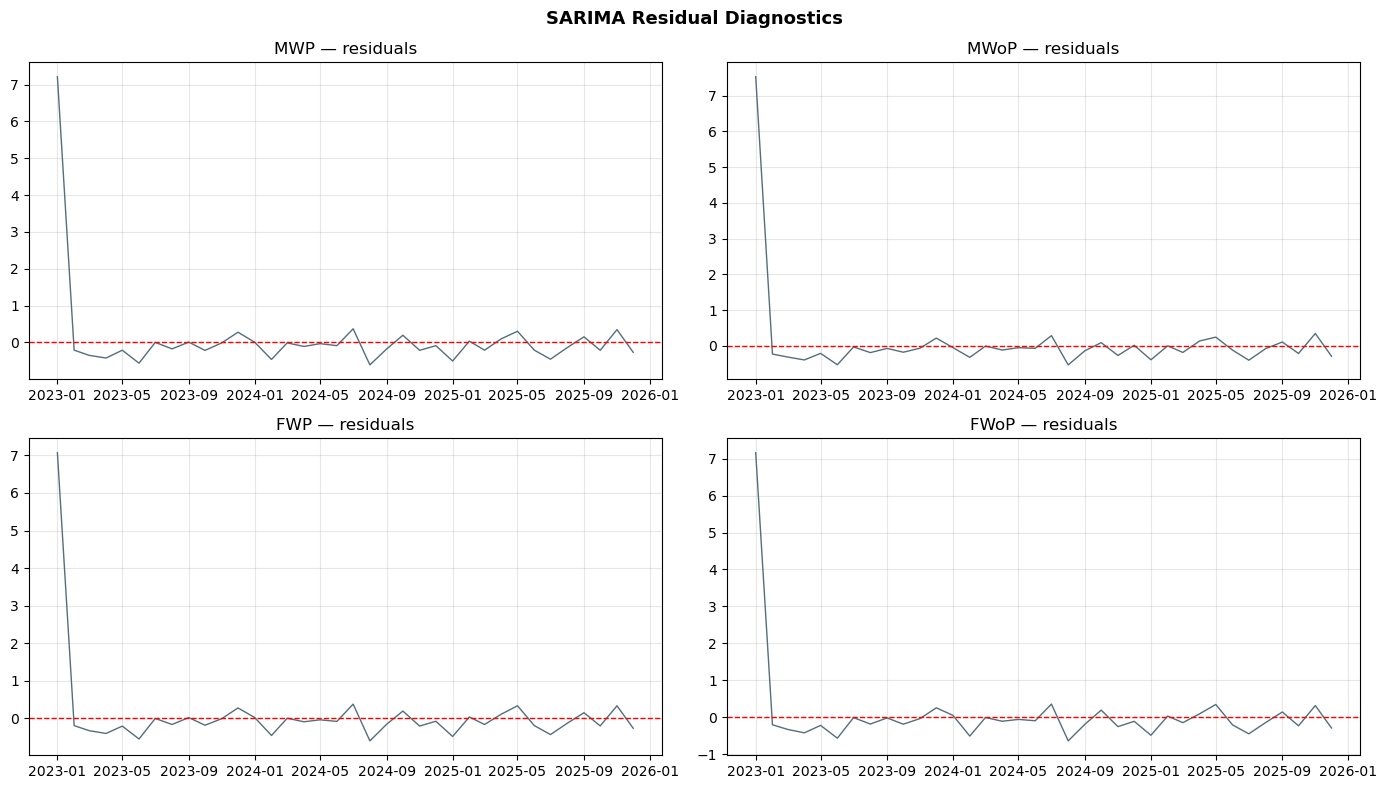

✅ Saved: outputs/gcpi_residuals.png


In [13]:
# Celda 6 — Diagnóstico de residuales
# Si el modelo es bueno, los residuales deben ser ruido blanco (no tienen patrón)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('SARIMA Residual Diagnostics', fontsize=13, fontweight='bold')

for ax, grupo in zip(axes.flat, ['MWP', 'MWoP', 'FWP', 'FWoP']):
    residuales = modelos[grupo].resid.dropna()
    ax.plot(residuales, color='#546E7A', linewidth=1)
    ax.axhline(0, color='red', linestyle='--', linewidth=1)
    ax.set_title(f"{grupo} — residuals")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/gcpi_residuals.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: outputs/gcpi_residuals.png")

In [14]:
# Celda 7 — Ljung-Box test: ¿los residuales son ruido blanco?
# H0: los residuales NO tienen autocorrelación (lo que queremos)
# Si p > 0.05 → modelo bien especificado
from statsmodels.stats.diagnostic import acorr_ljungbox

print("Ljung-Box Test on Residuals (lag=12)")
print("p > 0.05 = residuals are white noise = ✅ model is well specified\n")
print(f"{'Group':<8} {'LB stat':>10} {'p-value':>10} {'Result':>20}")
print("-" * 52)

for grupo, modelo in modelos.items():
    resid = modelo.resid.dropna()
    lb = acorr_ljungbox(resid, lags=[12], return_df=True)
    stat = lb['lb_stat'].values[0]
    p    = lb['lb_pvalue'].values[0]
    result = "✅ White noise" if p > 0.05 else "⚠️  Has structure"
    print(f"{grupo:<8} {stat:>10.4f} {p:>10.4f} {result:>20}")

Ljung-Box Test on Residuals (lag=12)
p > 0.05 = residuals are white noise = ✅ model is well specified

Group       LB stat    p-value               Result
----------------------------------------------------
MWP          0.5407     1.0000        ✅ White noise
MWoP         0.3820     1.0000        ✅ White noise
FWP          0.5364     1.0000        ✅ White noise
FWoP         0.5222     1.0000        ✅ White noise
